In [ ]:

# Importar las librerías necesarias para el análisis exploratorio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Cargar el archivo CSV
df = pd.read_csv('BankChurners.csv')

# Mostrar las primeras filas del dataset
print(df.head())


   CLIENTNUM     Attrition_Flag  Customer_Age Gender  Dependent_count  \
0  768805383  Existing Customer            45      M                3   
1  818770008  Existing Customer            49      F                5   
2  713982108  Existing Customer            51      M                3   
3  769911858  Existing Customer            40      F                4   
4  709106358  Existing Customer            40      M                3   

  Education_Level Marital_Status Income_Category Card_Category  \
0     High School        Married     $60K - $80K          Blue   
1        Graduate         Single  Less than $40K          Blue   
2        Graduate        Married    $80K - $120K          Blue   
3     High School        Unknown  Less than $40K          Blue   
4      Uneducated        Married     $60K - $80K          Blue   

   Months_on_book  ...  Credit_Limit  Total_Revolving_Bal  Avg_Open_To_Buy  \
0              39  ...       12691.0                  777          11914.0   
1       

In [ ]:

# Obtener información general del dataset (dimensiones, tipos de datos, valores nulos)
print('INFORMACIÓN GENERAL DEL DATASET')
print('=' * 80)
print('Dimensiones del dataset: ' + str(df.shape[0]) + ' filas, ' + str(df.shape[1]) + ' columnas')
print('\nTipos de datos:')
print(df.dtypes)
print('\nValores nulos por columna:')
print(df.isnull().sum())


INFORMACIÓN GENERAL DEL DATASET
Dimensiones del dataset: 10127 filas, 23 columnas

Tipos de datos:
CLIENTNUM                                                                                                                               int64
Attrition_Flag                                                                                                                         object
Customer_Age                                                                                                                            int64
Gender                                                                                                                                 object
Dependent_count                                                                                                                         int64
Education_Level                                                                                                                        object
Marital_Status                                   

In [ ]:

# Estadísticas descriptivas del dataset
print('ESTADÍSTICAS DESCRIPTIVAS')
print('=' * 80)
print(df.describe())


ESTADÍSTICAS DESCRIPTIVAS
          CLIENTNUM  Customer_Age  Dependent_count  Months_on_book  \
count  1.012700e+04  10127.000000     10127.000000    10127.000000   
mean   7.391776e+08     46.325960         2.346203       35.928409   
std    3.690378e+07      8.016814         1.298908        7.986416   
min    7.080821e+08     26.000000         0.000000       13.000000   
25%    7.130368e+08     41.000000         1.000000       31.000000   
50%    7.179264e+08     46.000000         2.000000       36.000000   
75%    7.731435e+08     52.000000         3.000000       40.000000   
max    8.283431e+08     73.000000         5.000000       56.000000   

       Total_Relationship_Count  Months_Inactive_12_mon  \
count              10127.000000            10127.000000   
mean                   3.812580                2.341167   
std                    1.554408                1.010622   
min                    1.000000                0.000000   
25%                    3.000000                2

In [ ]:

# Análisis de la variable objetivo (Attrition_Flag)
print('ANÁLISIS DE LA VARIABLE OBJETIVO - ATTRITION FLAG')
print('=' * 80)
attrition_counts = df['Attrition_Flag'].value_counts()
print(attrition_counts)
print('\nProporción:')
print(df['Attrition_Flag'].value_counts(normalize=True))


ANÁLISIS DE LA VARIABLE OBJETIVO - ATTRITION FLAG
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Proporción:
Attrition_Flag
Existing Customer    0.83934
Attrited Customer    0.16066
Name: proportion, dtype: float64


In [ ]:

# Análisis de variables categóricas
print('ANÁLISIS DE VARIABLES CATEGÓRICAS')
print('=' * 80)

# Obtener todas las columnas categóricas
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Iterar sobre cada columna categórica y mostrar sus valores únicos
for col in categorical_cols:
    print('\n' + col + ':')
    print(df[col].value_counts())


ANÁLISIS DE VARIABLES CATEGÓRICAS

Attrition_Flag:
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Gender:
Gender
F    5358
M    4769
Name: count, dtype: int64

Education_Level:
Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64

Marital_Status:
Marital_Status
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64

Income_Category:
Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64

Card_Category:
Card_Category
Blue        9436
Silver       555
Gold         116
Platinum      20
Name: count, dtype: int64


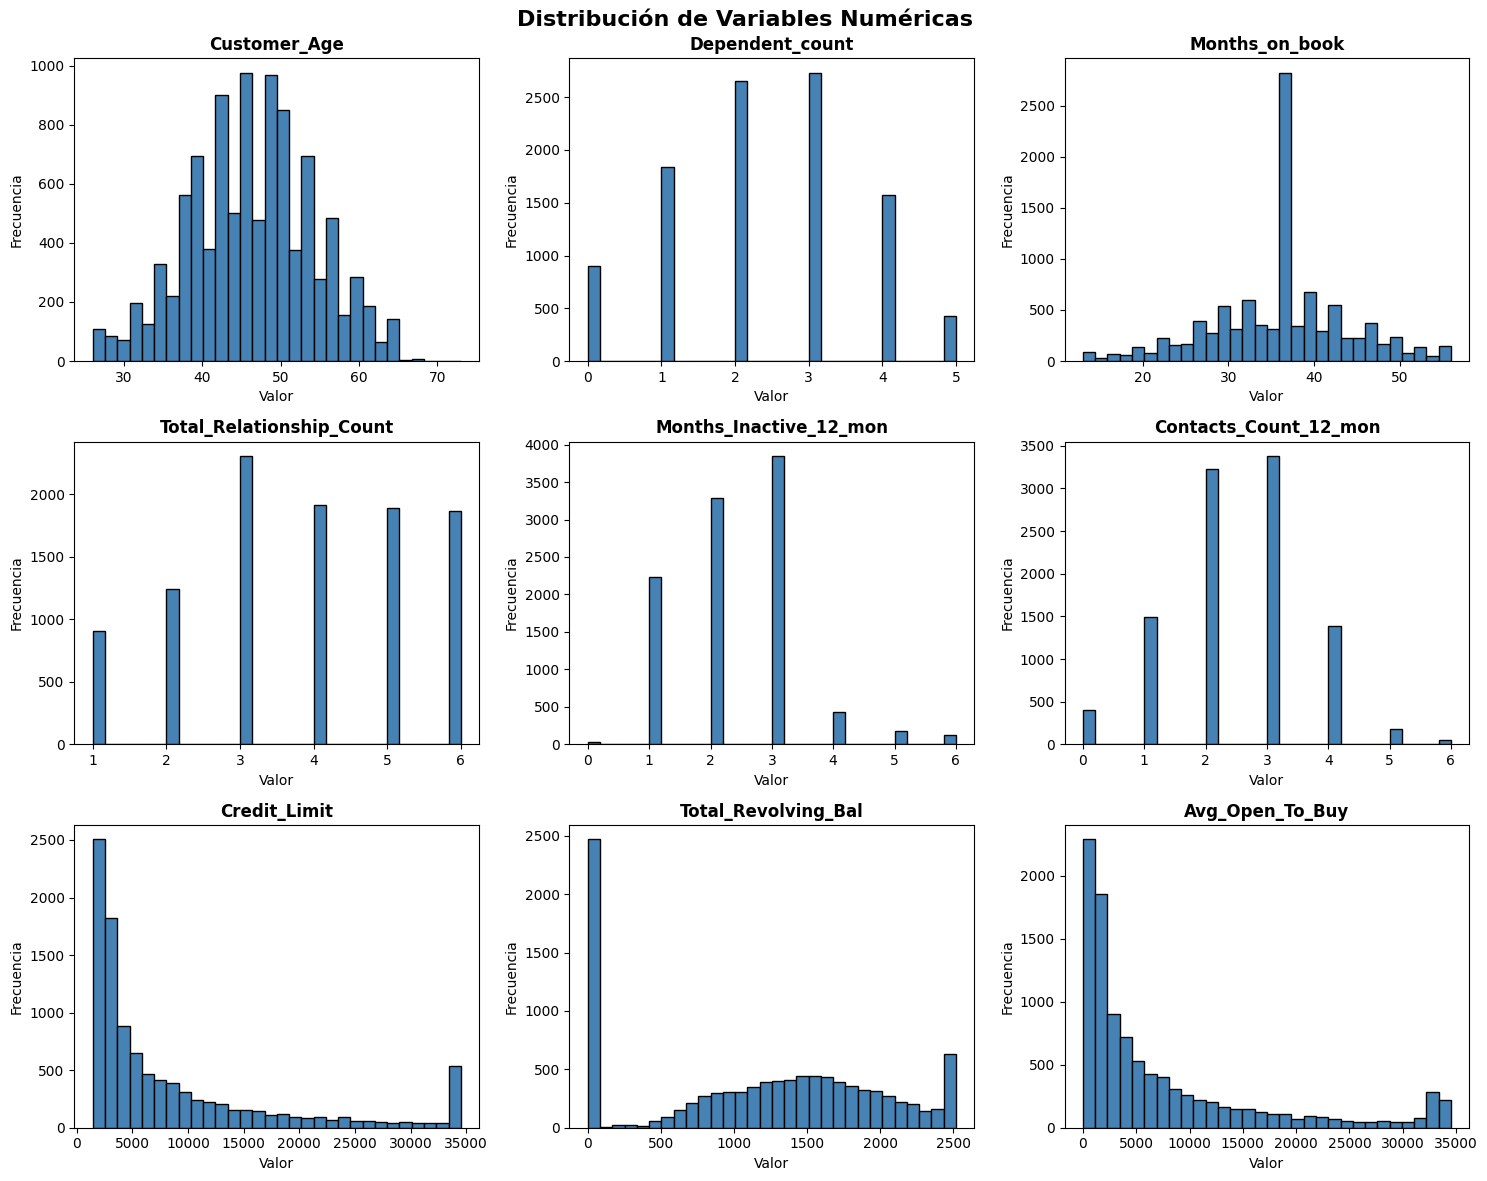

In [ ]:

# Crear visualizaciones para variables numéricas
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribución de Variables Numéricas', fontsize=16, fontweight='bold')

# Obtener columnas numéricas (excluyendo CLIENTNUM y las columnas de Naive Bayes)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'CLIENTNUM' and 'Naive_Bayes' not in col]

# Iterar sobre las primeras 9 columnas numéricas
for idx, col in enumerate(numeric_cols[:9]):
    row = idx // 3
    col_idx = idx % 3
    axes[row, col_idx].hist(df[col], bins=30, color='steelblue', edgecolor='black')
    axes[row, col_idx].set_title(col, fontweight='bold')
    axes[row, col_idx].set_xlabel('Valor')
    axes[row, col_idx].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


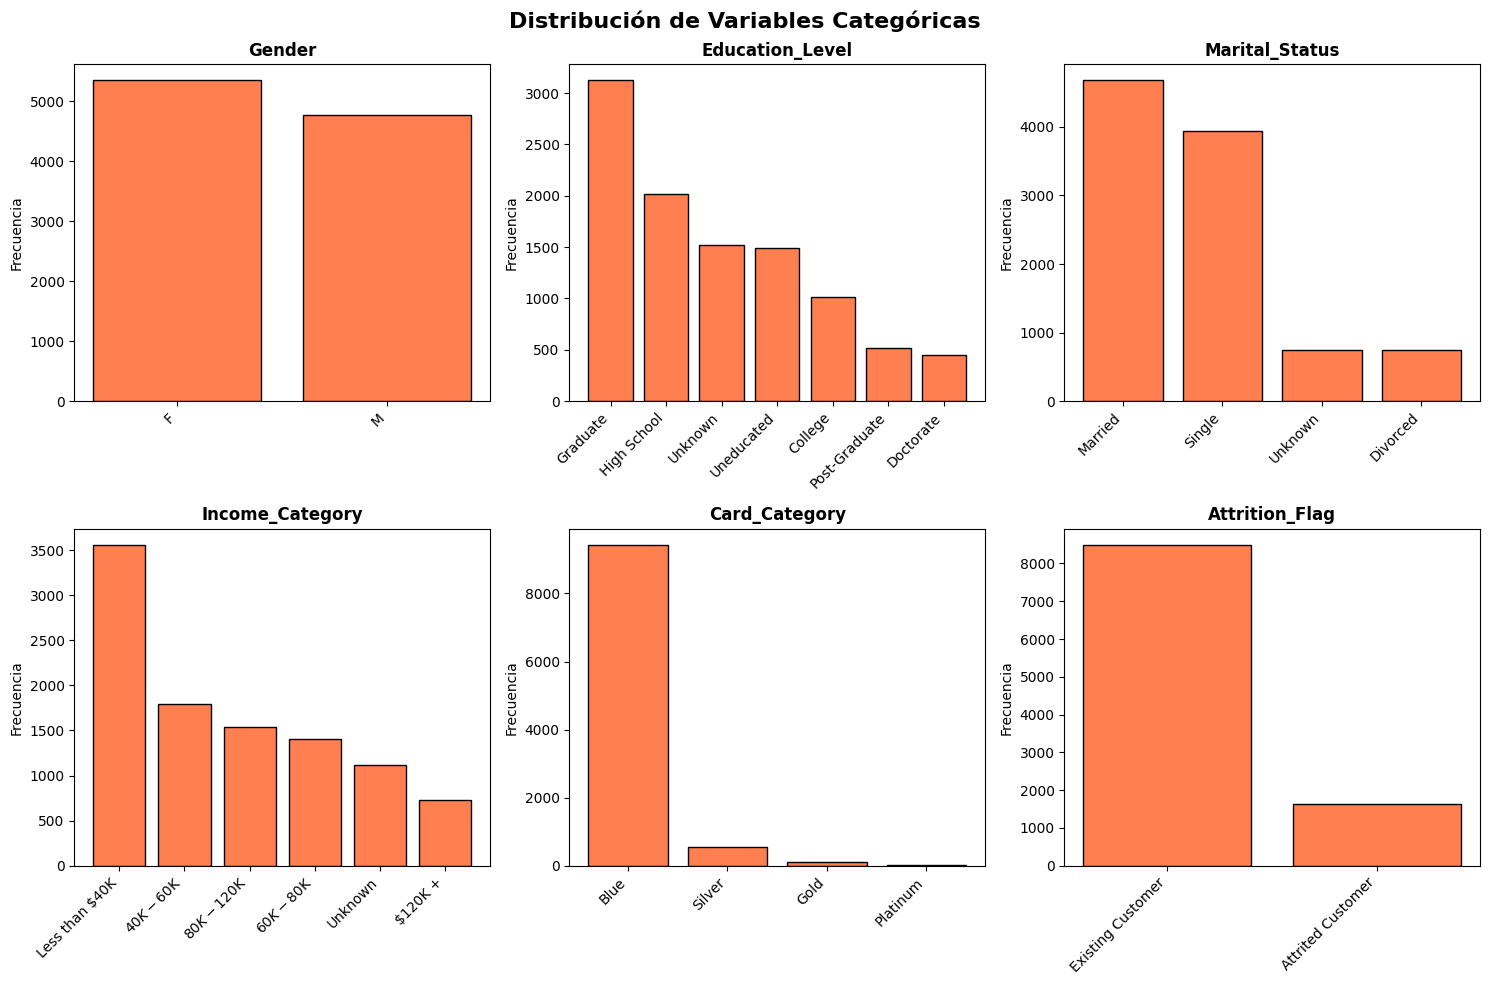

In [ ]:

# Crear visualizaciones para variables categóricas
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribución de Variables Categóricas', fontsize=16, fontweight='bold')

# Seleccionar las principales variables categóricas
cat_vars = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Attrition_Flag']

# Iterar sobre cada variable categórica
for idx, col in enumerate(cat_vars):
    row = idx // 3
    col_idx = idx % 3
    counts = df[col].value_counts()
    axes[row, col_idx].bar(range(len(counts)), counts.values, color='coral', edgecolor='black')
    axes[row, col_idx].set_xticks(range(len(counts)))
    axes[row, col_idx].set_xticklabels(counts.index, rotation=45, ha='right')
    axes[row, col_idx].set_title(col, fontweight='bold')
    axes[row, col_idx].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


MATRIZ DE CORRELACIÓN


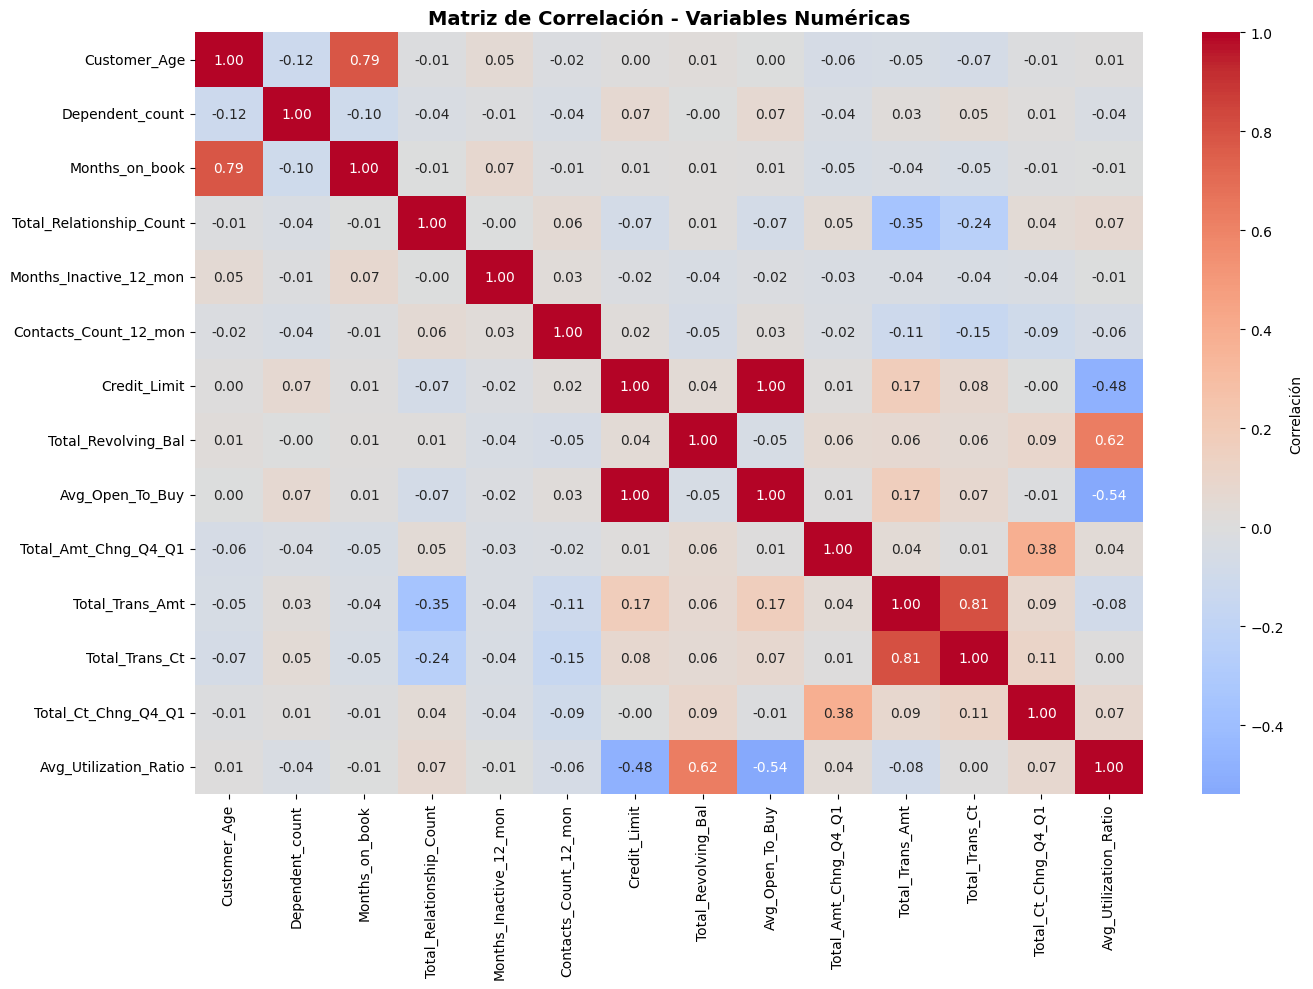

In [ ]:

# Análisis de correlación entre variables numéricas
print('MATRIZ DE CORRELACIÓN')
print('=' * 80)

# Seleccionar solo columnas numéricas relevantes (excluyendo CLIENTNUM y Naive Bayes)
numeric_cols_corr = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_corr = [col for col in numeric_cols_corr if col != 'CLIENTNUM' and 'Naive_Bayes' not in col]

# Calcular la matriz de correlación
correlation_matrix = df[numeric_cols_corr].corr()

# Crear un heatmap de la correlación
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, cbar_kws={'label': 'Correlación'})
plt.title('Matriz de Correlación - Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:

# Análisis de Attrition por variables categóricas
print('ANÁLISIS DE ATTRITION POR VARIABLES CATEGÓRICAS')
print('=' * 80)

# Crear una tabla cruzada para cada variable categórica
cat_vars = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

for col in cat_vars:
    print('\nAttrition por ' + col + ':')
    crosstab = pd.crosstab(df[col], df['Attrition_Flag'], margins=True)
    print(crosstab)

    # Calcular la tasa de attrition
    attrition_rate = pd.crosstab(df[col], df['Attrition_Flag'], normalize='index')
    print('\nTasa de Attrition por ' + col + ':')
    print(attrition_rate)


ANÁLISIS DE ATTRITION POR VARIABLES CATEGÓRICAS

Attrition por Gender:
Attrition_Flag  Attrited Customer  Existing Customer    All
Gender                                                     
F                             930               4428   5358
M                             697               4072   4769
All                          1627               8500  10127

Tasa de Attrition por Gender:
Attrition_Flag  Attrited Customer  Existing Customer
Gender                                              
F                        0.173572           0.826428
M                        0.146152           0.853848

Attrition por Education_Level:
Attrition_Flag   Attrited Customer  Existing Customer    All
Education_Level                                             
College                        154                859   1013
Doctorate                       95                356    451
Graduate                       487               2641   3128
High School                    306               

**ai_message:**

Hey there! 👋 I'm Julius, your AI assistant for data science. How can I help you today?

Whether you need to:
- **Analyze data** - Load files, explore datasets, create visualizations
- **Build models** - Train machine learning models, make predictions
- **Process information** - Clean data, transform datasets, generate insights
- **Create visualizations** - Charts, graphs, interactive dashboards
- **Or anything else data-related** - I'm here to help!

Just let me know what you'd like to work on, and feel free to upload any files you need using the paperclip button. What's on your mind?